Dataset loaded successfully! Shape: (4192, 106)


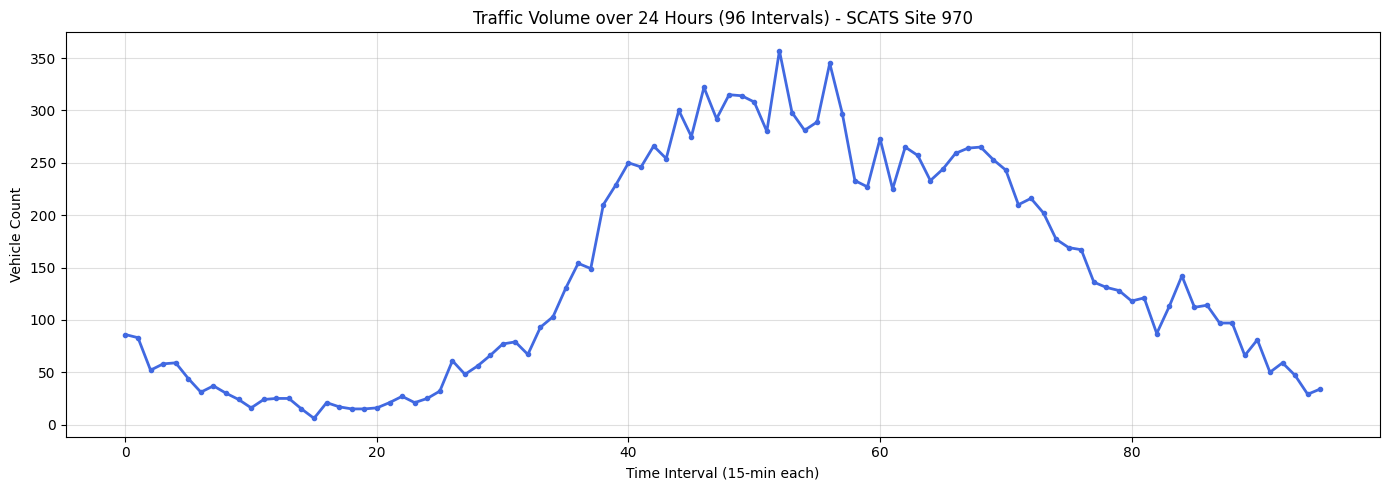

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Load the traffic dataset
# Note: Using '../data/' because the notebook is inside the 'notebooks' folder
file_path = '../data/scats_clean.csv'
df = pd.read_csv(file_path, sep=';', header=1)

print(f"Dataset loaded successfully! Shape: {df.shape}")

# 2. Extract 24-hour volume data (96 intervals of 15 minutes) for a specific SCATS site
volume_cols = [f"V{i:02d}" for i in range(96)]
site_id = 970
sample_data = df[df['SCATS Number'] == site_id].iloc[0][volume_cols].values

# 3. Plot the data
plt.figure(figsize=(14, 5))
plt.plot(sample_data, color='royalblue', linewidth=2, marker='o', markersize=3)
plt.title(f'Traffic Volume over 24 Hours (96 Intervals) - SCATS Site {site_id}')
plt.xlabel('Time Interval (15-min each)')
plt.ylabel('Vehicle Count')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [3]:
# Create a tiny dummy dataset to understand how time-series sequencing works
dummy_data = np.array([10, 20, 30, 40, 50, 60, 70, 80]).reshape(-1, 1)
time_step = 3 # Look back 3 steps to predict the 4th

X_sequences, y_targets = [], []

for i in range(len(dummy_data) - time_step):
    X_sequences.append(dummy_data[i : i + time_step])
    y_targets.append(dummy_data[i + time_step])

X_sequences = np.array(X_sequences)
y_targets = np.array(y_targets)

print("Original Time-Series Data:\n", dummy_data.flatten())
print("-" * 50)
print(f"Creating sequences with time_step = {time_step}...\n")

for i in range(len(X_sequences)):
    print(f"Sequence {i+1}: Input (Past {time_step} steps) = {X_sequences[i].flatten()} "
          f"--> Target (Next step) = {y_targets[i].flatten()}")

Original Time-Series Data:
 [10 20 30 40 50 60 70 80]
--------------------------------------------------
Creating sequences with time_step = 3...

Sequence 1: Input (Past 3 steps) = [10 20 30] --> Target (Next step) = [40]
Sequence 2: Input (Past 3 steps) = [20 30 40] --> Target (Next step) = [50]
Sequence 3: Input (Past 3 steps) = [30 40 50] --> Target (Next step) = [60]
Sequence 4: Input (Past 3 steps) = [40 50 60] --> Target (Next step) = [70]
Sequence 5: Input (Past 3 steps) = [50 60 70] --> Target (Next step) = [80]


In [4]:
import torch
import sys

# Add parent directory to sys.path to import custom modules
sys.path.append('../') 
from models import TrafficLSTM

# 1. Initialize the LSTM model architecture
model = TrafficLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)

# 2. Load the trained weights
# Make sure you have run train.py successfully before executing this
weights_path = '../models/lstm_best.pth'
try:
    model.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))
    model.eval() # Set model to evaluation mode
    print("Successfully loaded trained weights from lstm_best.pth!\n")
except FileNotFoundError:
    print(f"Error: Could not find {weights_path}. Did you run train.py?")

# 3. Print model architecture
print("Model Architecture:")
print(model)
print("-" * 50)

# 4. Perform a dummy forward pass
# Shape: (batch_size=1, sequence_length=12, features=1)
dummy_input = torch.randn(1, 12, 1) 

with torch.no_grad():
    prediction = model(dummy_input)

print(f"Input Tensor Shape : {dummy_input.shape}")
print(f"Output Tensor Shape: {prediction.shape} --> Predicted value: {prediction.item():.4f}")

Successfully loaded trained weights from lstm_best.pth!

Model Architecture:
TrafficLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
--------------------------------------------------
Input Tensor Shape : torch.Size([1, 12, 1])
Output Tensor Shape: torch.Size([1, 1]) --> Predicted value: 0.2542


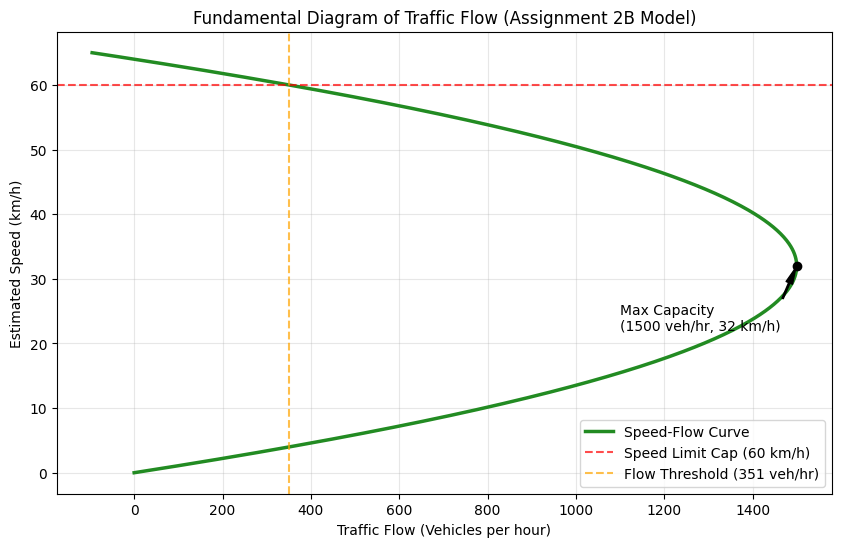

In [5]:
# Visualizing the Traffic Flow to Speed Conversion Formula
# Quadratic equation: flow = A * speed^2 + B * speed
A = -1.4648375
B = 93.75

# Generate speed values from 0 to 65 km/h
speeds = np.linspace(0, 65, 500)
# Calculate corresponding flows
flows = A * (speeds ** 2) + B * speeds

plt.figure(figsize=(10, 6))

# Plot the main curve
plt.plot(flows, speeds, color='forestgreen', linewidth=2.5, label='Speed-Flow Curve')

# Add threshold lines (as per project requirements)
plt.axhline(y=60, color='red', linestyle='--', alpha=0.7, label='Speed Limit Cap (60 km/h)')
plt.axvline(x=351, color='orange', linestyle='--', alpha=0.7, label='Flow Threshold (351 veh/hr)')

# Mark the maximum capacity point
max_flow = np.max(flows)
max_speed = speeds[np.argmax(flows)]
plt.plot(max_flow, max_speed, 'ko') # Black dot
plt.annotate(f'Max Capacity\n({max_flow:.0f} veh/hr, {max_speed:.0f} km/h)', 
             xy=(max_flow, max_speed), xytext=(max_flow-400, max_speed-10),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('Fundamental Diagram of Traffic Flow (Assignment 2B Model)')
plt.xlabel('Traffic Flow (Vehicles per hour)')
plt.ylabel('Estimated Speed (km/h)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
import torch
import sys

# 1. Import TrafficGRU from models.py
sys.path.append('../') 
from models import TrafficGRU

# 2. Initialize the GRU architecture (matching train.py settings)
gru_model = TrafficGRU(input_size=1, hidden_size=64, num_layers=2, dropout=0.2)

# 3. Load the best GRU weights
gru_weights_path = '../models/gru_best.pth'
try:
    gru_model.load_state_dict(torch.load(gru_weights_path, map_location=torch.device('cpu')))
    gru_model.eval()
    print("Successfully loaded trained weights from gru_best.pth!\n")
except FileNotFoundError:
    print(f"Error: Could not find {gru_weights_path}.")

# 4. Perform a dummy forward pass (Batch=1, TimeStep=12, Feature=1)
dummy_input = torch.randn(1, 12, 1) 

with torch.no_grad():
    gru_prediction = gru_model(dummy_input)

print(f"Input Tensor Shape : {dummy_input.shape}")
print(f"GRU Output Shape   : {gru_prediction.shape} --> Predicted value: {gru_prediction.item():.4f}")

Successfully loaded trained weights from gru_best.pth!

Input Tensor Shape : torch.Size([1, 12, 1])
GRU Output Shape   : torch.Size([1, 1]) --> Predicted value: 0.1386


In [7]:
import torch
import sys

# 1. Import TrafficTransformer from models.py
sys.path.append('../') 
from models import TrafficTransformer

# 2. Initialize the Transformer architecture (matching train.py settings)
transformer_model = TrafficTransformer(
    input_size=1, d_model=64, nhead=4, 
    num_encoder_layers=2, dim_feedforward=128, dropout=0.1
)

# 3. Load the best Transformer weights
trans_weights_path = '../models/transformer_best.pth'
try:
    transformer_model.load_state_dict(torch.load(trans_weights_path, map_location=torch.device('cpu')))
    transformer_model.eval()
    print("Successfully loaded trained weights from transformer_best.pth!\n")
except FileNotFoundError:
    print(f"Error: Could not find {trans_weights_path}.")

# 4. Perform a dummy forward pass
dummy_input = torch.randn(1, 12, 1) 

with torch.no_grad():
    trans_prediction = transformer_model(dummy_input)

print(f"Input Tensor Shape : {dummy_input.shape}")
print(f"Transformer Output : {trans_prediction.shape} --> Predicted value: {trans_prediction.item():.4f}")

Successfully loaded trained weights from transformer_best.pth!

Input Tensor Shape : torch.Size([1, 12, 1])
Transformer Output : torch.Size([1, 1]) --> Predicted value: 0.0415


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch

# 1. Load real data and fit the scaler (Similar to predict_flows in routing.py)
file_path = '../data/scats_clean.csv'
df = pd.read_csv(file_path, sep=';', header=1)
volume_cols = [f"V{i:02d}" for i in range(96)]

# Fit a global scaler just like in the data pipeline
all_volumes = []
for _, row in df.iterrows():
    vals = pd.to_numeric(row[volume_cols], errors="coerce").interpolate().ffill().bfill().fillna(0).tolist()
    all_volumes.extend(vals)

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(np.array(all_volumes, dtype=np.float32).reshape(-1, 1))

# 2. Extract 12 real data points from SCATS Site 2000 (Glenferrie Rd / Burwood Rd)
site_id = 2000
real_sequence = df[df['SCATS Number'] == site_id].iloc[0][volume_cols].values[-12:]
real_sequence = np.array(real_sequence, dtype=np.float32).reshape(-1, 1)

print(f"--- REAL TRAFFIC SEQUENCE (Past 12 intervals for SCATS {site_id}) ---")
print(real_sequence.flatten())
print("-" * 65)

# 3. Scale the input to [0, 1] range for models
scaled_sequence = scaler.transform(real_sequence)
input_tensor = torch.tensor(scaled_sequence, dtype=torch.float32).unsqueeze(0) # Shape: (1, 12, 1)

# 4. Make predictions using all 3 models
with torch.no_grad():
    # Make sure all models are in eval mode
    lstm_pred_scaled = model(input_tensor).numpy()
    gru_pred_scaled = gru_model(input_tensor).numpy()
    trans_pred_scaled = transformer_model(input_tensor).numpy()

# 5. Inverse transform back to real vehicle counts
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)[0, 0]
gru_pred = scaler.inverse_transform(gru_pred_scaled)[0, 0]
trans_pred = scaler.inverse_transform(trans_pred_scaled)[0, 0]

print("=== 🤖 AI PREDICTION RESULTS (Vehicles in the next 15 mins) ===")
print(f"🥇 LSTM Model Prediction       : {lstm_pred:.1f} vehicles")
print(f"🥈 GRU Model Prediction        : {gru_pred:.1f} vehicles")
print(f"🥉 Transformer Model Prediction: {trans_pred:.1f} vehicles")

--- REAL TRAFFIC SEQUENCE (Past 12 intervals for SCATS 2000) ---
[77. 69. 59. 52. 63. 37. 49. 34. 37. 24. 14. 13.]
-----------------------------------------------------------------
=== 🤖 AI PREDICTION RESULTS (Vehicles in the next 15 mins) ===
🥇 LSTM Model Prediction       : 22.4 vehicles
🥈 GRU Model Prediction        : 23.6 vehicles
🥉 Transformer Model Prediction: 27.7 vehicles
